# Modelo de Minería — Predicción de Recontacto (Árbol de Decisión)

**Objetivo:** ya sabemos, por el KPI 1, que la Tasa de Recontacto en 7 Días (TR7D) es alta (~40%).
Este notebook va un paso más allá: entrena un **árbol de decisión** para intentar *explicar* qué
combinación de variables hace que una interacción termine en recontacto, y confirmar o descartar
la hipótesis que dejamos anotada en `01_kpis_recontacto_duracion.ipynb` (Red social + duración corta → más recontacto).

**Variable de resultado (target):** `recontacto_7_dias` (1 = recontactó, 0 = no recontactó).

**Variables explicativas (features):** canal, motivo de contacto, cola de servicio, turno, tipo de
usuario, espera_seg, duracion_seg, transferencias, casos_previos_30d, si fue fin de semana.

No se usa `id_interaccion` ni `fecha_contacto` como variable explicativa: son identificadores/tiempo
crudo, no aportan patrón generalizable (usar la fecha exacta produciría un modelo que "memoriza"
en vez de aprender un patrón).

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from cargar_datos import cargar_dataset_modelo

df = cargar_dataset_modelo()
df.head()

📊 CARGANDO DATASET — Modelo de Recontacto (todas las variables)



📏 Dimensiones: 354 filas × 12 columnas

🎯 Distribución de la variable de resultado (recontacto_7_dias):
recontacto_7_dias
0    219
1    135
Name: count, dtype: int64


/home/abemilek/Documentos/workspace/servicio-ciudadano-mineria/proyecto/notebooks/../src/database.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, params=params) if params else pd.read_sql_query(query, conn)


,id_interaccion,canal,motivo_contacto,cola_servicio,turno,tipo_usuario,espera_seg,duracion_seg,transferencias,casos_previos_30d,es_fin_semana,recontacto_7_dias
0,C15-0001,Correo,Queja,Soporte,Nocturno,Adulto mayor,106,1009,0,0,False,0
1,C15-0002,Teléfono,Cobro,Soporte,Fin de semana,Nuevo,866,913,0,1,True,0
2,C15-0003,Correo,Cobro,Información,PM,Recurrente,564,855,0,5,False,0
3,C15-0004,Teléfono,Falla,Soporte,AM,Recurrente,815,727,3,0,False,1
4,C15-0005,Red social,Solicitud,Soporte,PM,Adulto mayor,242,1181,2,4,False,1


## 1. Preparar los datos

Los modelos de scikit-learn no entienden texto (`"Chat"`, `"Falla"`, etc.), solo números.
Convertimos cada variable categórica en columnas 0/1 con `pd.get_dummies` (una técnica llamada
*one-hot encoding*). No es que los datos "no sirvan" en texto — es que hay que traducirlos a un
formato que el algoritmo pueda procesar matemáticamente, tal como se explicó en clase.

In [2]:
columnas_categoricas = ['canal', 'motivo_contacto', 'cola_servicio', 'turno', 'tipo_usuario']
columnas_numericas = ['espera_seg', 'duracion_seg', 'transferencias', 'casos_previos_30d', 'es_fin_semana']

X = pd.get_dummies(df[columnas_categoricas + columnas_numericas], columns=columnas_categoricas)
y = df['recontacto_7_dias'].astype(int)

print(f"Features finales: {X.shape[1]} columnas (tras el one-hot encoding)")
print(f"Distribución del target:\n{y.value_counts(normalize=True).round(3) * 100}")
X.head()

Features finales: 28 columnas (tras el one-hot encoding)
Distribución del target:
recontacto_7_dias
0    61.9
1    38.1
Name: proportion, dtype: float64


,espera_seg,duracion_seg,transferencias,casos_previos_30d,es_fin_semana,canal_(sin dato),canal_Chat,canal_Correo,canal_Red social,canal_Teléfono,...,cola_servicio_Soporte,cola_servicio_Trámites,turno_AM,turno_Fin de semana,turno_Nocturno,turno_PM,tipo_usuario_Adulto mayor,tipo_usuario_Empresa,tipo_usuario_Nuevo,tipo_usuario_Recurrente
0,106,1009,0,0,False,False,False,True,False,False,...,True,False,False,False,True,False,True,False,False,False
1,866,913,0,1,True,False,False,False,False,True,...,True,False,False,True,False,False,False,False,True,False
2,564,855,0,5,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,815,727,3,0,False,False,False,False,False,True,...,True,False,True,False,False,False,False,False,False,True
4,242,1181,2,4,False,False,False,False,True,False,...,True,False,False,False,False,True,True,False,False,False


## 2. Separar en entrenamiento y prueba

Guardamos una parte de los datos (25%) que el modelo **nunca ve durante el entrenamiento**, para
evaluar honestamente qué tan bien generaliza — si lo evaluáramos con los mismos datos con los que
aprendió, no sabríamos si de verdad "entendió" el patrón o solo lo memorizó.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")

Entrenamiento: 265 filas | Prueba: 89 filas


## 3. Entrenar el árbol de decisión

Limitamos `max_depth=4` a propósito: un árbol muy profundo memoriza el ruido de los datos
(sobreajuste / *overfitting*) en vez de aprender un patrón general — y además sería ilegible para
explicárselo a un gerente. Con profundidad 4 el árbol sigue siendo interpretable a simple vista.

In [4]:
modelo = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(f"Exactitud (accuracy) en datos de prueba: {accuracy_score(y_test, y_pred):.2%}")
print()
print(classification_report(y_test, y_pred, target_names=['No recontacta (0)', 'Recontacta (1)']))

Exactitud (accuracy) en datos de prueba: 47.19%

                   precision    recall  f1-score   support

No recontacta (0)       0.56      0.67      0.61        55
   Recontacta (1)       0.22      0.15      0.18        34

         accuracy                           0.47        89
        macro avg       0.39      0.41      0.39        89
     weighted avg       0.43      0.47      0.44        89



**Cómo leer esto:** la exactitud (*accuracy*) sola no basta —un modelo que siempre dijera
"no recontacta" ya acertaría bastante seguido solo porque esa clase es mayoría. Por eso miramos
también *precision* y *recall* de la clase "Recontacta (1)": nos interesa sobre todo qué tan bien
detecta los casos que **sí** van a recontactar, porque son los que queremos prevenir.

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No recontacta', 'Recontacta'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión')
plt.show()

<Figure size 640x480 with 2 Axes>

## 4. ¿Qué variables pesan más? (importancia de variables)

Esto le responde directamente al gerente la pregunta *"¿en qué me tengo que fijar?"* — no todas las
variables aportan lo mismo para predecir el recontacto.

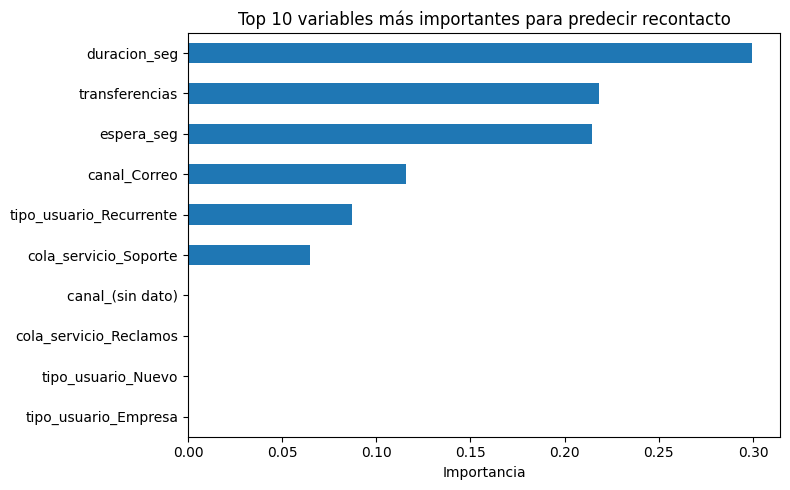

duracion_seg               0.299375
transferencias             0.218276
espera_seg                 0.214532
canal_Correo               0.115951
tipo_usuario_Recurrente    0.087005
cola_servicio_Soporte      0.064861
canal_(sin dato)           0.000000
cola_servicio_Reclamos     0.000000
tipo_usuario_Nuevo         0.000000
tipo_usuario_Empresa       0.000000
dtype: float64

In [6]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = importancias.head(10)

top10.plot(kind='barh', figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title('Top 10 variables más importantes para predecir recontacto')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

top10

## 5. Ver el árbol completo

Cada caja muestra: la condición que evalúa, cuántos casos caen ahí (`samples`), y cómo se reparten
entre las dos clases (`value = [no_recontacta, recontacta]`). Seguir el camino de la raíz hasta una
hoja es literalmente la "regla" que encontró el modelo.

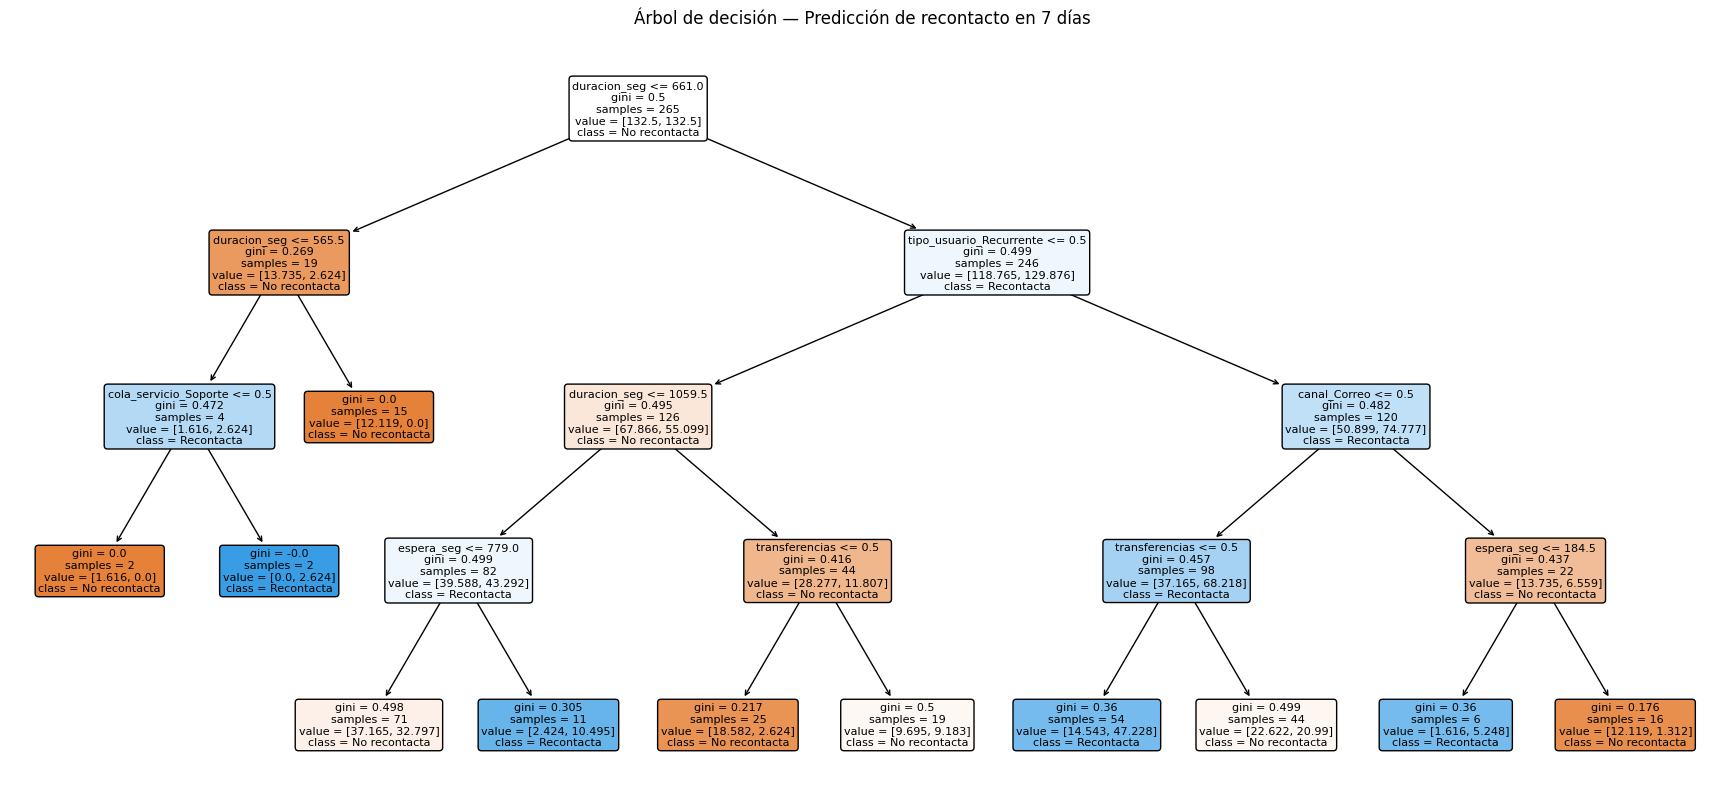

In [7]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['No recontacta', 'Recontacta'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Árbol de decisión — Predicción de recontacto en 7 días')
plt.show()

## 6. Conclusión (a completar por el equipo)

Con estos resultados, el equipo debe responder por escrito (para el informe / defensa):

- ¿Las variables más importantes confirman la hipótesis Red social + duración corta → más
  recontacto que quedó anotada en el notebook de KPIs? ¿O el árbol encontró algo distinto?
- ¿La exactitud y el recall de la clase "Recontacta" son aceptables, o hay que probar otro
  `max_depth`, balancear más las clases, o agregar/quitar variables?
- ¿Qué acción concreta sugeriría el equipo a Operaciones/Calidad a partir de la regla más
  importante del árbol (la que está más arriba, cerca de la raíz)?

*Nota: como el dataset sigue siendo el sintético (`generar_semilla.py`), estas conclusiones son
un ensayo del pipeline completo — quedan sujetas a repetirse cuando llegue el dataset real
`C15_CallCenter`.